In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect('sales.db')

In [3]:
cur = conn.cursor()

In [4]:
cur.execute(''' CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price INTEGER,
    quantity INTEGER
)
''')

In [5]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Phone', 'Tech', 400))

In [6]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Chair', 'Furniture', 40))

In [7]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Laptop', 'Tech', 800))

In [8]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Paper', 'Office', 200))

In [9]:
cur.execute("INSERT INTO products (product_name, category, price) VALUES (?,?,?)", ('Pen', 'Office', 10))

In [10]:
conn.commit()

In [11]:
cur.execute('SELECT * FROM products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(10, 'Paper', 'Office', 200)
(11, 'Pen', 'Office', 10)


In [12]:
cur.execute("UPDATE products SET price = 200 WHERE product_name='Pen'")

cur.execute('Select * from products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(10, 'Paper', 'Office', 200)
(11, 'Pen', 'Office', 200)


In [13]:
cur.execute("delete from products where product_name='Paper'")

cur.execute('select * from products')
rows = cur.fetchall()
for row in rows:
  print(row)

(1, 'Phone', 'Tech', 400)
(2, 'Chair', 'Furniture', 40)
(3, 'Laptop', 'Tech', 800)
(5, 'Pen', 'Office', 200)
(6, 'Laptop', 'Tech', 800)
(7, 'Phone', 'Tech', 400)
(8, 'Chair', 'Furniture', 40)
(9, 'Laptop', 'Tech', 800)
(11, 'Pen', 'Office', 200)


In [14]:
data = pd.read_sql_query('select * from products', conn)

<ipython-input-15-3d53d64201c6>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=data, palette = 'viridis')


<Axes: xlabel='category', ylabel='count'>

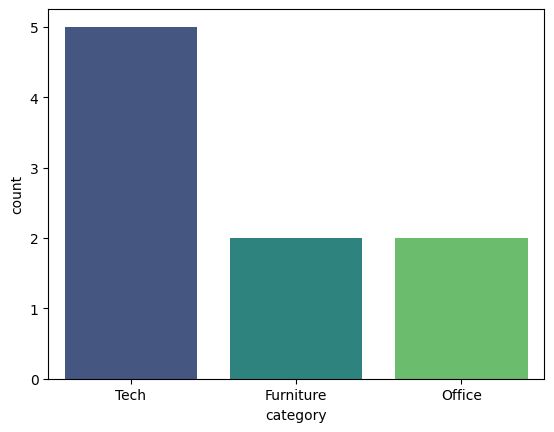

In [15]:
sns.countplot(x='category', data=data, palette = 'viridis')

In [16]:
cur.execute("insert into products (product_name, category, price) VALUES (?,?,?)", ('Table', 'Furniture', 43))

In [17]:
cur.execute("insert into products (product_name, category, price) VALUES (?,?,?)", ('Car', 'Automotive', 600))

<Axes: ylabel='Frequency'>

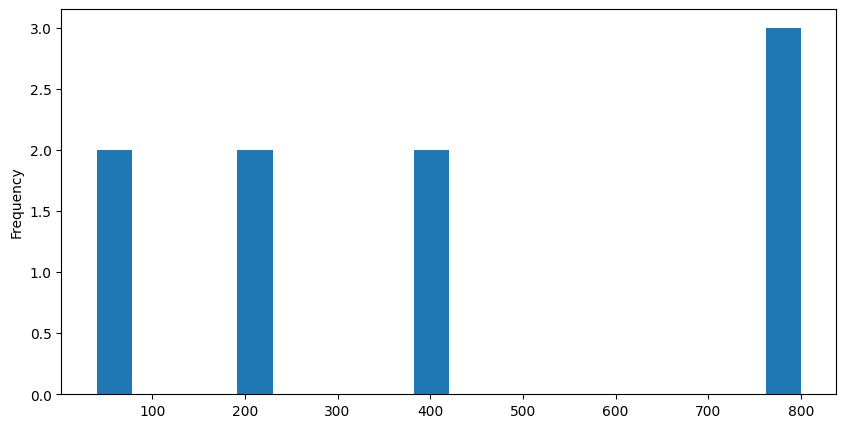

In [19]:
data['price'].plot.hist(bins=20, figsize=(10,5))

([<matplotlib.patches.Wedge at 0x7eba77888110>,
 [Text(1.0364870175126868, 0.3683675644348395, 'Phone'),
  Text(0.8290843452828609, 0.7229240267184996, 'Chair'),
  Text(0.14978336653292748, 1.089754533420285, 'Laptop'),
  Text(-0.7229238652898036, 0.8290844860413504, 'Pen'),
  Text(-1.0999999999999874, 1.6609537900762079e-07, 'Laptop'),
  Text(-0.571542679370119, -0.9398611416897846, 'Phone'),
  Text(-0.186901890511231, -1.0840053889733796, 'Chair'),
  Text(0.571542253624808, -0.939861400591319, 'Laptop'),
  Text(1.0840054194235482, -0.18690171390433388, 'Pen')],
 [Text(0.56535655500692, 0.20092776241900331, '10.9%'),
  Text(0.45222782469974226, 0.39432219639190885, '1.1%'),
  Text(0.08170001810886952, 0.5944115636837917, '21.7%'),
  Text(-0.3943221083398928, 0.4522279014771001, '5.4%'),
  Text(-0.5999999999999931, 9.059747945870224e-08, '21.7%'),
  Text(-0.31175055238370125, -0.5126515318307916, '10.9%'),
  Text(-0.1019464857333987, -0.5912756667127524, '1.1%'),
  Text(0.3117503201589

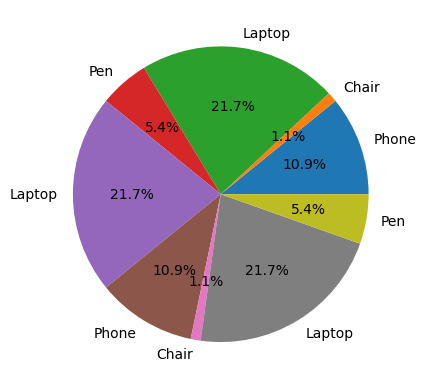

In [46]:
plt.pie(data['price'], labels=data['product_name'], autopct='%1.1f%%')

<ipython-input-21-e784e32055ac>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=data, palette = 'viridis')


<Axes: xlabel='count', ylabel='category'>

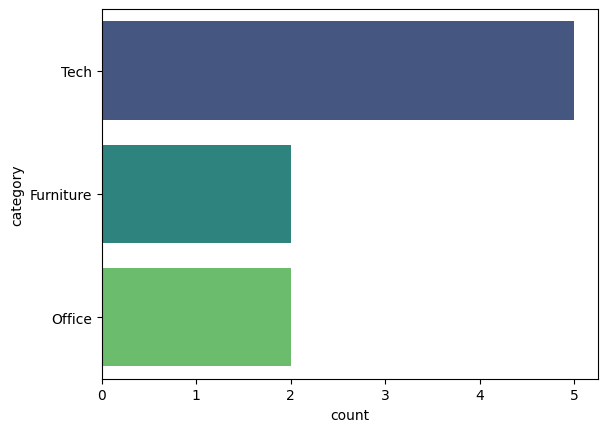

In [21]:
sns.countplot(y='category', data=data, palette = 'viridis')

In [25]:
data1 = data.drop('product_id', axis = 1)

<Axes: >

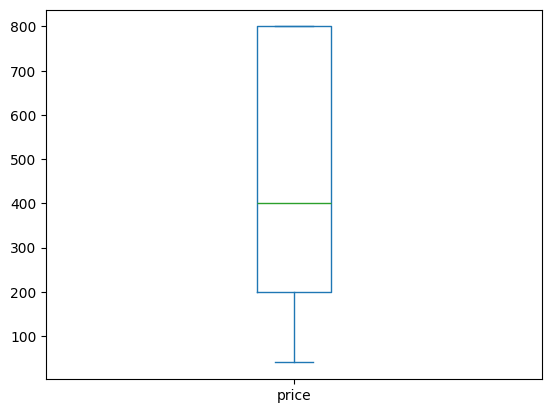

In [27]:
data1.plot(kind='box')

In [31]:
data2 = pd.read_sql_query('select * from products', conn)

In [32]:
data2.head()

,product_id,product_name,category,price
0,1,Phone,Tech,400
1,2,Chair,Furniture,40
2,3,Laptop,Tech,800
3,5,Pen,Office,200
4,6,Laptop,Tech,800


In [33]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    11 non-null     int64 
 1   product_name  11 non-null     object
 2   category      11 non-null     object
 3   price         11 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 484.0+ bytes


In [35]:
data2.count()

,0
product_id,11
product_name,11
category,11
price,11


In [36]:
data2.duplicated().sum()

np.int64(0)

In [37]:
data2.isnull().sum()

,0
product_id,0
product_name,0
category,0
price,0


In [39]:
data_cat = data.select_dtypes(include='object')
data_num = data.select_dtypes(include=np.number)

In [43]:
data_cat.value_counts()

,,count
product_name,category,
Laptop,Tech,3
Chair,Furniture,2
Pen,Office,2
Phone,Tech,2


In [44]:
data_num.describe()

,product_id,price
count,9.000000,9.000000
mean,5.777778,408.888889
std,3.345810,319.861081
min,1.000000,40.000000
25%,3.000000,200.000000
50%,6.000000,400.000000
75%,8.000000,800.000000
max,11.000000,800.000000


In [45]:
data_num.corr()

,product_id,price
product_id,1.000000,-0.007268
price,-0.007268,1.000000
